In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()

In [2]:
learning_rate = 1e-3
batch_size = 64
epochs = 5

In [3]:
# Define loss function
loss_fn = nn.CrossEntropyLoss()

# Use Adam instead of SGD
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [4]:
model_results = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

In [5]:
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        # Forward pass
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backward + optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        total_loss += loss.item()
        correct += (pred.argmax(1) == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total

    print(f"Train   | Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")
    return avg_loss, accuracy

In [6]:
def test_loop(dataloader, model, loss_fn):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            pred = model(X)
            loss = loss_fn(pred, y)

            total_loss += loss.item()
            correct += (pred.argmax(1) == y).sum().item()
            total += y.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total

    print(f"Test    | Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")
    return avg_loss, accuracy

In [8]:
model_results = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    print("-" * 30)

    train_loss, train_acc = train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loss, test_acc = test_loop(test_dataloader, model, loss_fn)

    model_results["train_loss"].append(train_loss)
    model_results["train_acc"].append(train_acc)
    model_results["test_loss"].append(test_loss)
    model_results["test_acc"].append(test_acc)


Epoch 1/5
------------------------------
Train   | Loss: 0.4907, Accuracy: 0.8218
Test    | Loss: 0.4149, Accuracy: 0.8477

Epoch 2/5
------------------------------
Train   | Loss: 0.3602, Accuracy: 0.8671
Test    | Loss: 0.4018, Accuracy: 0.8515

Epoch 3/5
------------------------------
Train   | Loss: 0.3211, Accuracy: 0.8800
Test    | Loss: 0.3751, Accuracy: 0.8633

Epoch 4/5
------------------------------
Train   | Loss: 0.2928, Accuracy: 0.8903
Test    | Loss: 0.3763, Accuracy: 0.8601

Epoch 5/5
------------------------------
Train   | Loss: 0.2707, Accuracy: 0.8979
Test    | Loss: 0.3526, Accuracy: 0.8710


In [9]:
from torchsummary import summary

model = NeuralNetwork()
model.to(device)

# Print summary for input shape [batch_size, channels, height, width]
summary(model, input_size=(1, 28, 28))  # FashionMNIST has 1 channel, 28x28

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 512]         401,920
              ReLU-3                  [-1, 512]               0
            Linear-4                  [-1, 512]         262,656
              ReLU-5                  [-1, 512]               0
            Linear-6                   [-1, 10]           5,130
Total params: 669,706
Trainable params: 669,706
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 2.55
Estimated Total Size (MB): 2.58
----------------------------------------------------------------


In [10]:
# Save the model's state dict
torch.save(model.state_dict(), "model.pth")
print("Saved model to model.pth")

Saved model to model.pth


In [11]:
model.load_state_dict(torch.load('model.pth'))

<All keys matched successfully>

In [12]:
model.eval()

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)

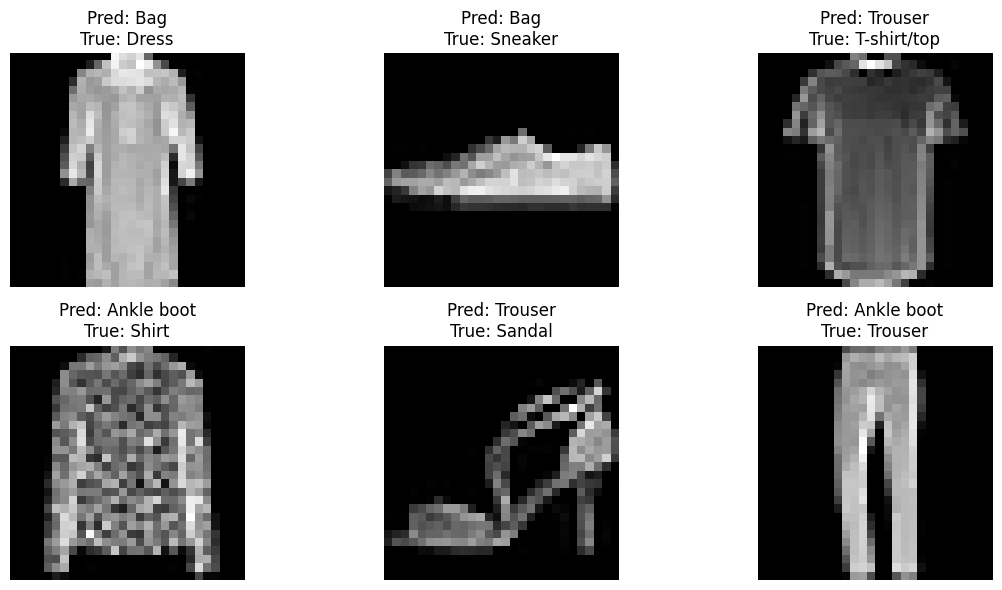

In [18]:
import random

# Put model in eval mode
model.eval()

# Class labels
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Convert the entire test dataset to list
test_dataset = test_dataloader.dataset

# Pick N random samples
num_images = 6
indices = random.sample(range(len(test_dataset)), num_images)

plt.figure(figsize=(12, 6))
with torch.no_grad():
    for i, idx in enumerate(indices):
        image, label = test_dataset[idx]  # Single sample
        image_batch = image.unsqueeze(0)  # Add batch dim: [1, 1, 28, 28]

        # Predict
        output = model(image_batch)
        pred = output.argmax(1).item()

        # Plot
        plt.subplot(2, 3, i + 1)
        plt.imshow(image.squeeze(), cmap="gray")  # from [1, 28, 28] to [28, 28]
        plt.title(f"Pred: {class_names[pred]}\nTrue: {class_names[label]}")
        plt.axis("off")

plt.tight_layout()
plt.show()

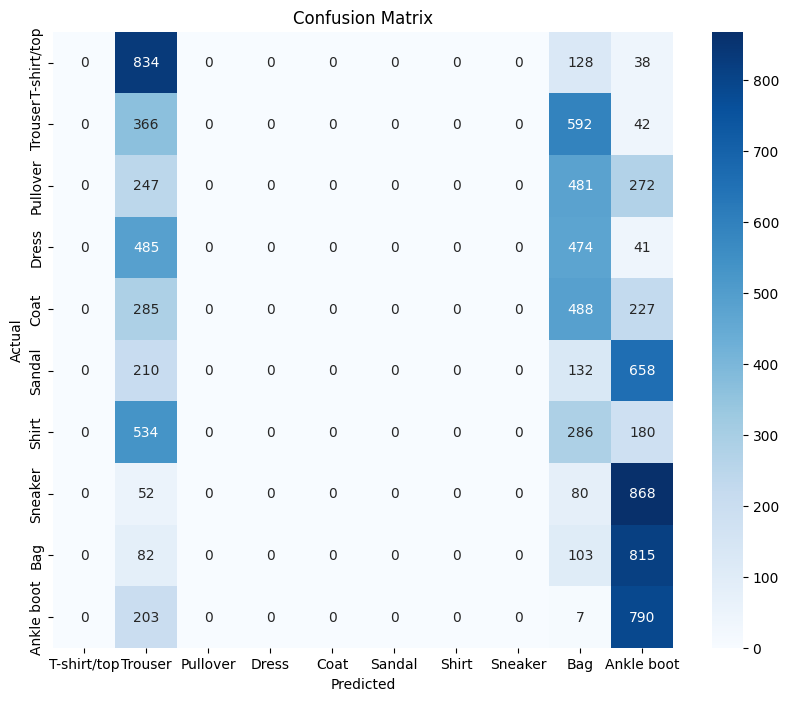


FashionMNIST Model Summary:
Model Architecture: NeuralNetwork
Total Parameters: 669,706
Training Epochs: 5
Final Training Accuracy: 0.8979
Final Test Accuracy: 0.8710
Final Training Loss: 0.2707
Final Test Loss: 0.3526
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [16]:
from sklearn.metrics import accuracy_score
from torchmetrics.classification import ConfusionMatrix
import seaborn as sns

# Make sure model is in eval mode
model.eval()

# Predict on test set
y_true = []
y_preds = []

with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        pred = logits.argmax(dim=1)
        y_preds.append(pred.cpu())
        y_true.append(y.cpu())

# Concatenate all predictions and labels
y_pred_tensor = torch.cat(y_preds)
y_true_tensor = torch.cat(y_true)

# ✅ Accuracy (using sklearn)
test_accuracy = accuracy_score(y_true_tensor, y_pred_tensor)

# ✅ Confusion matrix (torchmetrics)
confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
conf_matrix = confmat(y_pred_tensor, y_true_tensor)

# ✅ Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix.numpy(), annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ✅ Print summary
print("\nFashionMNIST Model Summary:")
print("=" * 50)
print(f"Model Architecture: {model.__class__.__name__}")
print(f"Total Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Training Epochs: {epochs}")
print(f"Final Training Accuracy: {model_results['train_acc'][-1]:.4f}")
print(f"Final Test Accuracy: {model_results['test_acc'][-1]:.4f}")
print(f"Final Training Loss: {model_results['train_loss'][-1]:.4f}")
print(f"Final Test Loss: {model_results['test_loss'][-1]:.4f}")
print(f"Classes: {class_names}")
print("=" * 50)